In [1]:
import csv, torch, numpy as np, random
import pandas as pd
from ac2 import ActorCritic, get_legal_move_indices, idx_to_move
from chessrl import Env, SyzygyDefender, RandomDefender
import torch, numpy as np

2025-09-02 15:24:43,046 - INFO - Loading config file...


## unit test of subfunctions

In [23]:
from chessrl.utils.fen_parsing import parse_fen

def extract_coords7_from_fen(fen: str) -> torch.Tensor:
    """
    Return [wx, wy, rx, ry, bx, by, side] normalized to [-1,1].
    Assumes parse_fen -> [8,8,12] with channels:
      white: P=0,N=1,B=2,R=3,Q=4,K=5 ; black king k=11
    """
    board = parse_fen(fen)  # [8,8,12]
    wk = torch.nonzero(board[:,:,5],  as_tuple=False)[0].tolist()  # row, col
    wr = torch.nonzero(board[:,:,3],  as_tuple=False)[0].tolist()
    bk = torch.nonzero(board[:,:,11], as_tuple=False)[0].tolist()
    wy, wx = wk; ry, rx = wr; by, bx = bk
    side = 1.0 if fen.split()[1] == 'w' else -1.0
    return wy, wx, ry, rx, by, bx, side

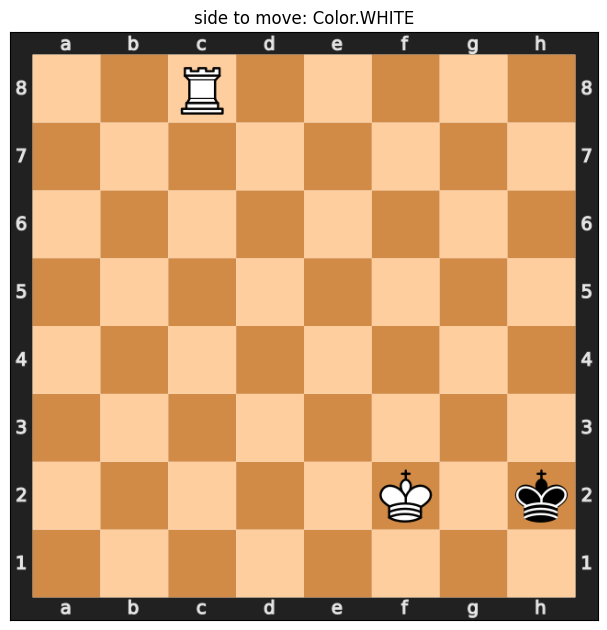

In [44]:
fen = '2R5/8/8/8/8/8/5K1k/8 w - - 0 1'

test_env = Env.from_fen(fen)
test_env.display_state()

In [45]:
extract_coords7_from_fen(fen)

(6, 5, 0, 2, 6, 7, 1.0)

### value function

In [39]:
def value_features_phi8(fen: str) -> np.ndarray:
    """
    phi(s) = [1, d_edge(BK)/3, dxK/6, dyK/6, dxR/6, dyR/6, side, rook_present]
    If the rook is missing, set dxR=dyR=1.0 and rook_present=0.0.
    dx,dy use max(0, |Δ|-1) then scale.
    """
    b = parse_fen(fen)  # [8,8,12]

    def find_one(ch):
        idx = torch.nonzero(b[:, :, ch], as_tuple=False)
        return idx[0].tolist() if idx.numel() > 0 else None

    bk = find_one(11)  # black king
    wk = find_one(5)   # white king
    wr = find_one(3)   # white rook (may be None)
    assert bk is not None and wk is not None, f"Invalid KRK FEN (missing king): {fen}"

    bk_r, bk_c = bk
    wk_r, wk_c = wk

    def dxdy(wx, wy):
        dx = max(0, abs(wx - bk_c) - 1)
        dy = max(0, abs(wy - bk_r) - 1)
        return dx, dy

    dxk, dyk = dxdy(wk_c, wk_r)

    if wr is None:
        dxr = dyr = 1.0   # treat as "very far / useless" when rook is gone
        rook_present = 0.0
    else:
        wr_r, wr_c = wr
        dxr, dyr = dxdy(wr_c, wr_r)
        rook_present = 1.0

    d_edge = min(bk_r, 7 - bk_r, bk_c, 7 - bk_c)
    side = 1.0 if fen.split()[1] == 'w' else -1.0

    return np.array([1.0, d_edge, dxk, dyk, dxr, dyr, side, rook_present], dtype=np.float32)

In [46]:
value_features_phi8('2R5/8/8/8/8/8/5K1k/8 w - - 0 1')

array([1., 0., 1., 0., 4., 5., 1., 1.], dtype=float32)

## train ac

In [28]:
def set_seed(s=0):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)

def load_fens_from_csv(csv_path, limit=None):
    fens = []
    with open(csv_path, newline='') as f:
        r = csv.DictReader(f)
        for row in r:
            fen = row["fen"]
            # make sure it's White to move
            if " w " in fen.split(" ", 2)[1:2] or fen.split()[1] == 'w':
                fens.append(fen)
                if limit and len(fens) >= limit: break
    return fens
set_seed(0)
device = torch.device('cpu')

csv_path = "../../../../tablebase/krk/krk_train.csv"   # <-- point to your CSV (fen,side,wdl,dtz)
fens = load_fens_from_csv(csv_path, limit=5000)  # start with 50k WTM positions
df = pd.read_csv(csv_path)
fens = df[df['dtz'] == 1]['fen'].tolist()
fens[1]

'2R5/8/8/8/8/8/5K1k/8 w - - 0 1'

In [33]:
ac = ActorCritic(
    tb_path="../../../../tablebase/krk/",
    gamma=0.95,
    lr_v=2e-2,
    lr_a=2e-3,
    hidden=(128,128,64),
)
# ac.load("policy_mlp.pt", "critic_w.npy", device=torch.device('cpu'))

In [50]:
losses, rewards = ac.train(
    fens[:100],
    epochs=50,
    device=device,
    max_steps=3
)

ac.save("policy_mlp.pt", "critic_w.npy")
print("Saved to policy_mlp.pt and critic_w.npy")

Epoch 50/50: 100%|██████████| 100/100 [00:01<00:00, 85.36it/s, G_discounted=0.000, ep_reward=0.00, steps=3] 


Saved to policy_mlp.pt and critic_w.npy


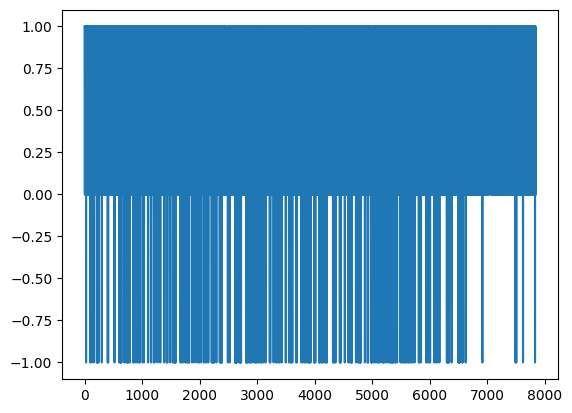

In [51]:
import matplotlib.pyplot as plt

plt.plot(rewards)

In [45]:
def evaluate(policy_path, critic_path, fens, max_steps=64):
    ac = ActorCritic(tb_path="../../../../tablebase/krk/")
    ac.load(policy_path, critic_path, device=torch.device('cpu'))
    ac.policy.eval()
    wins = 0
    for fen in fens:
        env = Env.from_fen(fen, two_ply_cost=0.0, draw_penalty=1.0, checkmate_reward=1.0,
                           defender=SyzygyDefender(tb_path="../../../../tablebase/krk/"))
        steps = 0
        done = False
        while not done and steps < max_steps:
            legal = get_legal_move_indices(env)
            a_idx = ac.policy.get_action_greedy(env, legal)  # greedy-ish
            uci = idx_to_move[a_idx]
            step = env.step(uci)
            done = step.done
            steps += 1
        if env.state().is_checkmate():
            wins += 1
    return wins / len(fens)

In [52]:

# usage:
sr = evaluate("policy_mlp.pt", "critic_w.npy", fens[:100], max_steps=3)
print("Success rate:", sr)


Success rate: 0.74
